Python Data Cleaning and Visualization - 03/22/2026 - chrlyl2361

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("AirBnBSummary_v2.xlsx")

In [3]:
df.head()

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
0,7909479,41706311,David,Downtown,Entire home/apt,107.0,30,27,365.0,NaN
1,15966488,103700433,Erin,Downtown,Entire home/apt,100.0,1,250,74.0,NaN
2,19859814,103700433,Erin,Downtown,Entire home/apt,100.0,1,309,79.0,NaN
3,21071138,22992627,Joseph,Downtown,Entire home/apt,100.0,2,144,338.0,NaN
4,21712505,103700433,Erin,Downtown,Entire home/apt,100.0,1,178,68.0,NaN


In [4]:
df = df.drop_duplicates()

In [5]:
df.head()

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
0,7909479,41706311,David,Downtown,Entire home/apt,107.0,30,27,365.0,NaN
1,15966488,103700433,Erin,Downtown,Entire home/apt,100.0,1,250,74.0,NaN
2,19859814,103700433,Erin,Downtown,Entire home/apt,100.0,1,309,79.0,NaN
3,21071138,22992627,Joseph,Downtown,Entire home/apt,100.0,2,144,338.0,NaN
4,21712505,103700433,Erin,Downtown,Entire home/apt,100.0,1,178,68.0,NaN


In [3]:
df['room_type'] = df['room_type'].replace("Private room", "Private Room")
df['room_type'].value_counts()

room_type
Entire home/apt    1539
Private Room        240
Name: count, dtype: int64

In [4]:
df['price'] = df['price'].fillna(df['price'].median())
df['minimum_nights'] = df['minimum_nights'].fillna(df['minimum_nights'].median())
df['number_of_reviews'] = df['number_of_reviews'].fillna(df['number_of_reviews'].median())
df['availability_365'] = df['availability_365'].fillna(df['availability_365'].median())

In [5]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]
df.head()

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
0,7909479,41706311,David,Downtown,Entire home/apt,107.0,30,27,365.0,NaN
1,15966488,103700433,Erin,Downtown,Entire home/apt,100.0,1,250,74.0,NaN
2,19859814,103700433,Erin,Downtown,Entire home/apt,100.0,1,309,79.0,NaN
3,21071138,22992627,Joseph,Downtown,Entire home/apt,100.0,2,144,338.0,NaN
4,21712505,103700433,Erin,Downtown,Entire home/apt,100.0,1,178,68.0,NaN


In [6]:
df.to_excel("AirBnBSummary_v2_Python_Cleaned.xlsx", index=False)

In [7]:
print("Total Listings:", len(df))
print("Minimum Price:", df['price'].min())
print("Maximum Price:", df['price'].max())
print("Mean Price:", df['price'].mean())
print("Median Reviews:", df['number_of_reviews'].median())
print("Mode Minimum Nights:", df['minimum_nights'].mode()[0])
print("Standard Deviation:", df['price'].std())
print("Correlation:", df['price'].corr(df['availability_365']))

Total Listings: 1661
Minimum Price: 20.0
Maximum Price: 308.0
Mean Price: 124.18904274533413
Median Reviews: 20.0
Mode Minimum Nights: 1
Standard Deviation: 61.57787038238736
Correlation: 0.10640950901815427


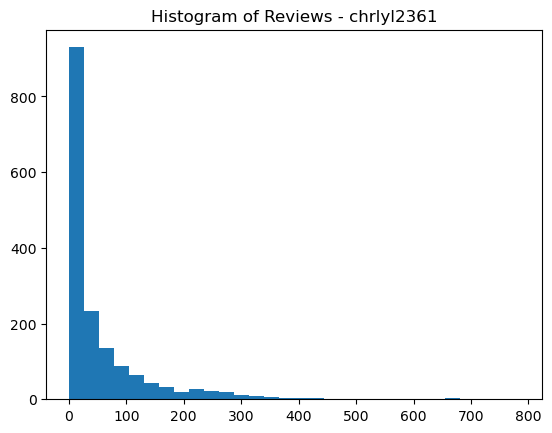

In [8]:
plt.figure()
plt.hist(df['number_of_reviews'], bins=30)
plt.title("Histogram of Reviews - chrlyl2361")
plt.show()

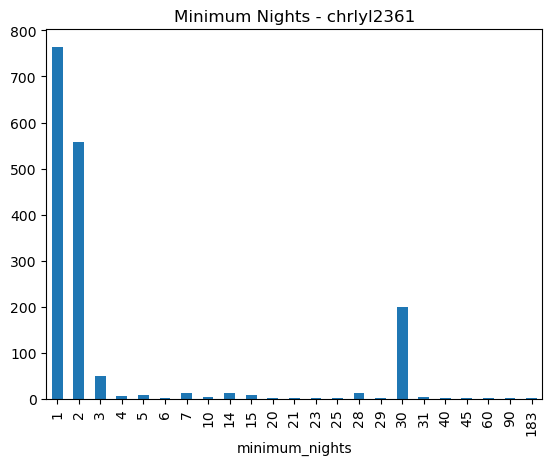

In [9]:
plt.figure()
df['minimum_nights'].value_counts().sort_index().plot(kind='bar')
plt.title("Minimum Nights - chrlyl2361")
plt.show()

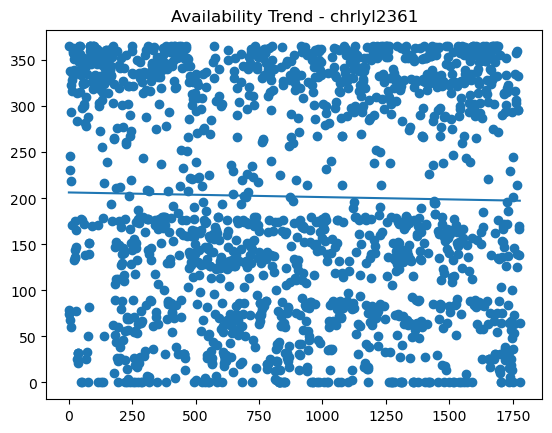

In [10]:
plt.figure()
plt.scatter(df.index, df['availability_365'])

z = np.polyfit(df.index, df['availability_365'], 1)
p = np.poly1d(z)
plt.plot(df.index, p(df.index))

plt.title("Availability Trend - chrlyl2361")
plt.show()

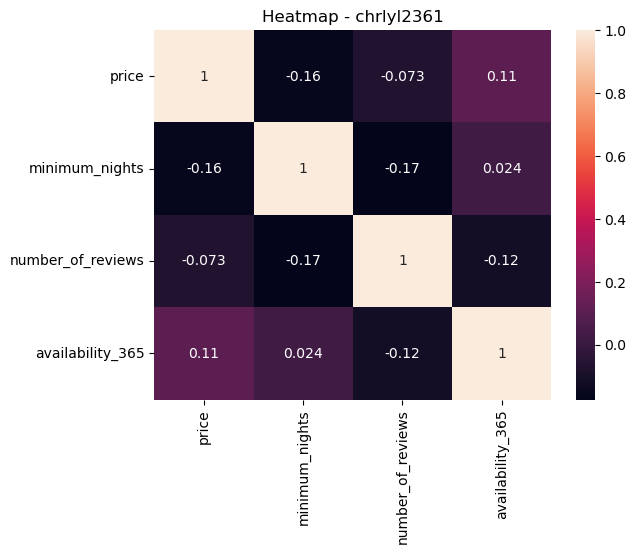

In [11]:
plt.figure()
corr = df[['price','minimum_nights','number_of_reviews','availability_365']].corr()
sns.heatmap(corr, annot=True)
plt.title("Heatmap - chrlyl2361")
plt.show()